# Déployez un modèle dans le cloud
## Projet Fruits! — Pipeline Big Data avec PySpark & AWS

**El Haouzi Saoussan — OpenClassrooms Data Scientist**

---

## Sommaire

**1. Préambule**
- 1.1 Problématique
- 1.2 Objectifs
- 1.3 Déroulement du projet

**2. Choix techniques**
- 2.1 Calcul distribué avec Apache Spark
- 2.2 Transfer Learning avec MobileNet
- 2.3 Broadcast des poids du modèle

**3. Déploiement local**
- 3.1 Environnement de travail
- 3.2 Chargement des images
- 3.3 Extraction de features (MobileNet)
- 3.4 Création du DataFrame Spark
- 3.5 Preprocessing & PCA

**4. Déploiement sur le cloud AWS**
- 4.1 Configuration S3
- 4.2 Pipeline complet sur EC2
- 4.3 Résultats et validation

# 1. Préambule

## 1.1 Problématique

La start-up **Fruits!** souhaite proposer des solutions innovantes pour la récolte des fruits.
Elle développe des robots cueilleurs intelligents et une **application mobile** permettant aux utilisateurs
de prendre en photo un fruit et d'obtenir des informations dessus.

Cette application nécessite un **moteur de classification d'images** capable de traiter
un volume croissant de données.

## 1.2 Objectifs

- Mettre en place une infrastructure **Big Data scalable** sur AWS
- Réaliser une chaîne de traitement : **preprocessing** + **réduction de dimension (PCA)**
- Respecter les contraintes **RGPD** (serveurs en Europe)
- Le code doit pouvoir passer à l'échelle **sans modification**

## 1.3 Déroulement

Le projet se déroule en **2 temps** :
1. Développement et validation en **local** sur un sous-ensemble (5 catégories)
2. Déploiement en **production sur AWS** (EC2 + S3 + IAM)

# 2. Choix techniques

## 2.1 Calcul distribué avec Apache Spark

PySpark permet de distribuer les calculs sur plusieurs cœurs (local) ou plusieurs machines (cluster EMR).
Le même code s'exécute en local et en production sans modification.

## 2.2 Transfer Learning avec MobileNet

MobileNet est un réseau de neurones pré-entraîné sur ImageNet.
On utilise le **transfer learning** : on récupère les features de l'avant-dernière couche
(1024 dimensions) sans entraîner de modèle.

## 2.3 Broadcast des poids du modèle

Dans un environnement distribué, chaque worker Spark a besoin du modèle MobileNet.
Sans broadcast : chaque worker recharge le modèle (200 Mo) depuis le disque → très lent.
Avec **broadcast** : le driver envoie les poids UNE SEULE FOIS à tous les workers → beaucoup plus rapide.

```python
# Principe du broadcast
brodcast_weights = sc.broadcast(new_model.get_weights())
new_model.set_weights(brodcast_weights.value)  # Dans chaque worker
```

# 3. Déploiement local

## 3.1 Environnement de travail

In [1]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import pyspark
import tensorflow as tf
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras import Model

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, element_at, split, pandas_udf, PandasUDFType
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml import Pipeline

print("PySpark version      :", pyspark.__version__)
print("TensorFlow version   :", tf.__version__)
print("NumPy version        :", np.__version__)
print("Tout est prêt !")

PySpark version      : 3.3.2
TensorFlow version   : 2.12.0
NumPy version        : 1.23.5
Tout est prêt !


## 3.2 Configuration Java & SparkSession

In [2]:
# Configuration Java (Windows local)
os.environ["JAVA_HOME"] = "C:/Program Files/OpenLogic/jdk-11.0.23.9-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin;" + os.environ["PATH"]
os.environ["PYSPARK_PYTHON"] = "python"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python"

# Création de la SparkSession
# local[*] = utilise tous les cœurs disponibles du processeur
spark = SparkSession.builder \
    .appName("Fruits_BigData_Pipeline") \
    .master("local[*]") \
    .config("spark.sql.parquet.writeLegacyFormat", "true") \
    .getOrCreate()

# SparkContext — nécessaire pour le broadcast des poids
sc = spark.sparkContext

print("Spark OK :", spark.version)
print("Cores disponibles :", sc.defaultParallelism)

Spark OK : 3.3.2
Cores disponibles : 4


## 3.3 Exploration du dataset

### 3.3.1 Chargement des catégories

In [3]:
# Chemin vers le dataset local
DATA_PATH = Path("E:/fruits-360/fruits-360_dataset/fruits-360/Training")

# Lister toutes les catégories
categories = [f.name for f in DATA_PATH.iterdir() if f.is_dir()]
print(f"Nombre total de catégories : {len(categories)}")
print("Exemples :", categories[:10])

Nombre total de catégories : 131
Exemples : ['Apple Braeburn', 'Apple Crimson Snow', 'Apple Golden 1', 'Apple Golden 2', 'Apple Golden 3', 'Apple Granny Smith', 'Apple Pink Lady', 'Apple Red 1', 'Apple Red 2', 'Apple Red 3']


### 3.3.2 Sélection d'un échantillon de 5 catégories

In [4]:
# On garde seulement 5 catégories pour le développement local
categories_sample = categories[:5]
print("Catégories sélectionnées :", categories_sample)

# Compter les images par catégorie
total = 0
for cat in categories_sample:
    nb_images = len(list((DATA_PATH / cat).glob("*.jpg")))
    print(f"  {cat} : {nb_images} images")
    total += nb_images
print(f"\nTotal : {total} images")

Catégories sélectionnées : ['Apple Braeburn', 'Apple Crimson Snow', 'Apple Golden 1', 'Apple Golden 2', 'Apple Golden 3']
  Apple Braeburn : 492 images
  Apple Crimson Snow : 444 images
  Apple Golden 1 : 480 images
  Apple Golden 2 : 492 images
  Apple Golden 3 : 481 images

Total : 2389 images


### 3.3.3 Visualisation de quelques images

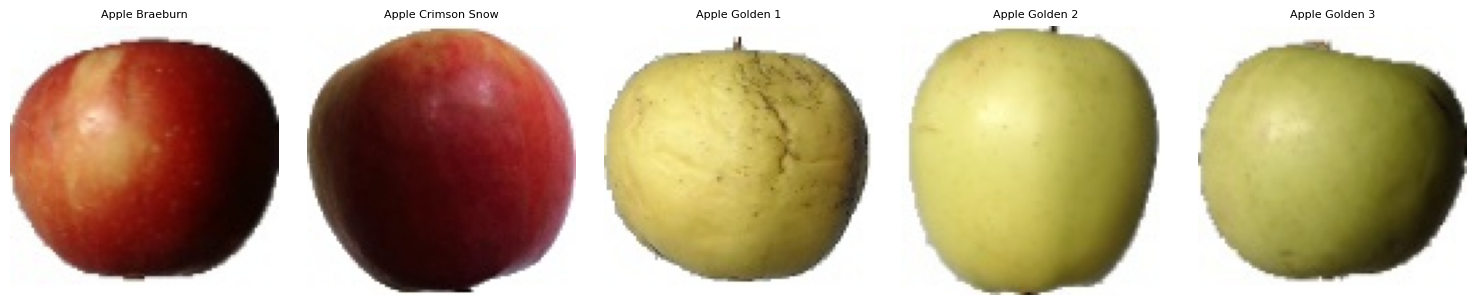

In [5]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, cat in enumerate(categories_sample):
    img_path = list((DATA_PATH / cat).glob("*.jpg"))[0]
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cat, fontsize=8)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 3.4 Préparation du modèle MobileNet

On utilise MobileNet **sans la dernière couche** (pas de classification).
On récupère un vecteur de **1024 features** par image via l'avant-dernière couche.

In [6]:
# Charger MobileNet pré-entraîné sur ImageNet
# include_top=False + pooling='avg' → sortie de 1024 features par image
model = MobileNet(weights="imagenet", include_top=False, pooling="avg")
print("MobileNet chargé !")
print(f"Dimension des features en sortie : {model.output_shape}")  # (None, 1024)

MobileNet chargé !
Dimension des features en sortie : (None, 1024)


## 3.5 Broadcast des poids du modèle

**Point clé du projet** : on diffuse les poids du modèle à tous les workers Spark.
Cela évite que chaque worker recharge MobileNet depuis le disque (200 Mo × N workers).

Le driver envoie les poids une seule fois → chaque worker reconstruit le modèle localement.

In [7]:
# Broadcast des poids sur tous les workers Spark
# C'est la technique recommandée pour le transfer learning distribué
brodcast_weights = sc.broadcast(model.get_weights())
print("Poids broadcastés avec succès !")
print(f"Nombre de couches : {len(brodcast_weights.value)}")

def model_fn():
    """
    Reconstruit MobileNet dans chaque worker à partir des poids broadcastés.
    Évite de recharger le modèle 200 Mo depuis le disque à chaque task.
    """
    m = MobileNet(weights=None, include_top=False, pooling="avg")
    m.set_weights(brodcast_weights.value)
    return m

Poids broadcastés avec succès !
Nombre de couches : 135


## 3.6 Extraction des features

On extrait les 1024 features par image en utilisant MobileNet.

In [9]:
# Version optimisée — on charge le modèle UNE SEULE FOIS
model_extract = model_fn()  # chargé une seule fois

all_features = []
all_labels = []

for cat in categories_sample:
    images = list((DATA_PATH / cat).glob("*.jpg"))
    print(f"Traitement de {cat} ({len(images)} images)...")
    
    # Traiter toutes les images d'un coup en batch
    batch = []
    for img_path in images:
        img = keras_image.load_img(img_path, target_size=(224, 224))
        img_array = keras_image.img_to_array(img)
        img_array = preprocess_input(img_array)
        batch.append(img_array)
    
    batch = np.array(batch)
    features = model_extract.predict(batch, verbose=0, batch_size=32)
    
    all_features.extend(features)
    all_labels.extend([cat] * len(images))
    print(f"  -> {len(images)} images traitées !")

all_features = np.array(all_features)
print(f"\nShape finale : {all_features.shape}")
print(f"Nombre total d'images : {len(all_labels)}")

Traitement de Apple Braeburn (492 images)...
  -> 492 images traitées !
Traitement de Apple Crimson Snow (444 images)...
  -> 444 images traitées !
Traitement de Apple Golden 1 (480 images)...
  -> 480 images traitées !
Traitement de Apple Golden 2 (492 images)...
  -> 492 images traitées !
Traitement de Apple Golden 3 (481 images)...
  -> 481 images traitées !

Shape finale : (2389, 1024)
Nombre total d'images : 2389


## 3.7 Création du DataFrame Spark

In [10]:
# Convertir les features numpy en vecteurs Spark
data = [(Vectors.dense(all_features[i].tolist()), all_labels[i])
        for i in range(len(all_labels))]

df_spark = spark.createDataFrame(data, ["features_raw", "label"])
print(f"DataFrame Spark créé : {df_spark.count()} lignes")
df_spark.show(5, truncate=True)
df_spark.printSchema()

DataFrame Spark créé : 2389 lignes
+--------------------+--------------+
|        features_raw|         label|
+--------------------+--------------+
|[0.03795683011412...|Apple Braeburn|
|[0.04805931821465...|Apple Braeburn|
|[0.08248520642518...|Apple Braeburn|
|[0.03642984479665...|Apple Braeburn|
|[0.03855955228209...|Apple Braeburn|
+--------------------+--------------+
only showing top 5 rows

root
 |-- features_raw: vector (nullable = true)
 |-- label: string (nullable = true)



## 3.8 Preprocessing & Réduction de dimension (PCA)

### 3.8.1 Pipeline PySpark

On enchaîne :
1. **StandardScaler** : normalise les features (moy=0, std=1) — obligatoire avant PCA
2. **PCA** : réduit les dimensions en gardant les composantes les plus importantes

On cherche d'abord k optimal en testant plusieurs valeurs.

In [11]:
# ── Étape 1 : k=50 pour tester ──
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

pca_50 = PCA(k=50, inputCol="features_scaled", outputCol="features_pca")
pipeline_50 = Pipeline(stages=[scaler, pca_50])
model_50 = pipeline_50.fit(df_spark)
df_50 = model_50.transform(df_spark)

# Variance expliquée
variance_50 = model_50.stages[-1].explainedVariance.toArray()
print(f"Variance avec k=50 : {np.cumsum(variance_50)[-1]:.2%}")
print("Pipeline k=50 terminé !")

Variance avec k=50 : 75.35%
Pipeline k=50 terminé !


In [12]:
# ── Étape 2 : k=200 ──
pca_200 = PCA(k=200, inputCol="features_scaled", outputCol="features_pca")
pipeline_200 = Pipeline(stages=[scaler, pca_200])
model_200 = pipeline_200.fit(df_spark)
df_200 = model_200.transform(df_spark)

variance_200 = model_200.stages[-1].explainedVariance.toArray()
variance_cum_200 = np.cumsum(variance_200)
print(f"Variance avec k=200  : {variance_cum_200[-1]:.2%}")
print(f"Variance à k=50      : {variance_cum_200[49]:.2%}")
print(f"Variance à k=100     : {variance_cum_200[99]:.2%}")
print(f"Variance à k=150     : {variance_cum_200[149]:.2%}")

Variance avec k=200  : 92.28%
Variance à k=50      : 75.35%
Variance à k=100     : 85.31%
Variance à k=150     : 89.65%


In [13]:
# ── Étape 3 : k=300 pour trouver le seuil 95% ──
pca_300 = PCA(k=300, inputCol="features_scaled", outputCol="features_pca")
pipeline_300 = Pipeline(stages=[scaler, pca_300])
model_300 = pipeline_300.fit(df_spark)
df_300 = model_300.transform(df_spark)

variance_300 = model_300.stages[-1].explainedVariance.toArray()
variance_cum_300 = np.cumsum(variance_300)
print(f"Variance avec k=300 : {variance_cum_300[-1]:.2%}")

Variance avec k=300 : 95.38%


In [14]:
# ── Calcul du k optimal ──
k_optimal = int(np.argmax(variance_cum_300 >= 0.95)) + 1
print(f"K optimal pour 95% de variance : {k_optimal} composantes")
print(f"Réduction : 1024 dimensions → {k_optimal} composantes")
print(f"Compression : {((1024 - k_optimal) / 1024 * 100):.1f}%")

K optimal pour 95% de variance : 284 composantes
Réduction : 1024 dimensions → 284 composantes
Compression : 72.3%


### 3.8.2 Pipeline final avec k optimal

In [15]:
# ── Pipeline final avec k=284 ──
pca_final = PCA(k=k_optimal, inputCol="features_scaled", outputCol="features_pca")
pipeline_final = Pipeline(stages=[scaler, pca_final])
model_final = pipeline_final.fit(df_spark)
df_final = model_final.transform(df_spark)

print("Pipeline final terminé !")
print(f"Dimensions finales : {df_final.select('features_pca').first()[0].size} composantes")
df_final.select("label", "features_pca").show(5, truncate=True)

Pipeline final terminé !
Dimensions finales : 284 composantes
+--------------+--------------------+
|         label|        features_pca|
+--------------+--------------------+
|Apple Braeburn|[9.92187644155752...|
|Apple Braeburn|[11.0666166028795...|
|Apple Braeburn|[9.88533768479230...|
|Apple Braeburn|[11.5000695608080...|
|Apple Braeburn|[11.6312446381442...|
+--------------+--------------------+
only showing top 5 rows



## 3.9 Visualisation de la variance expliquée

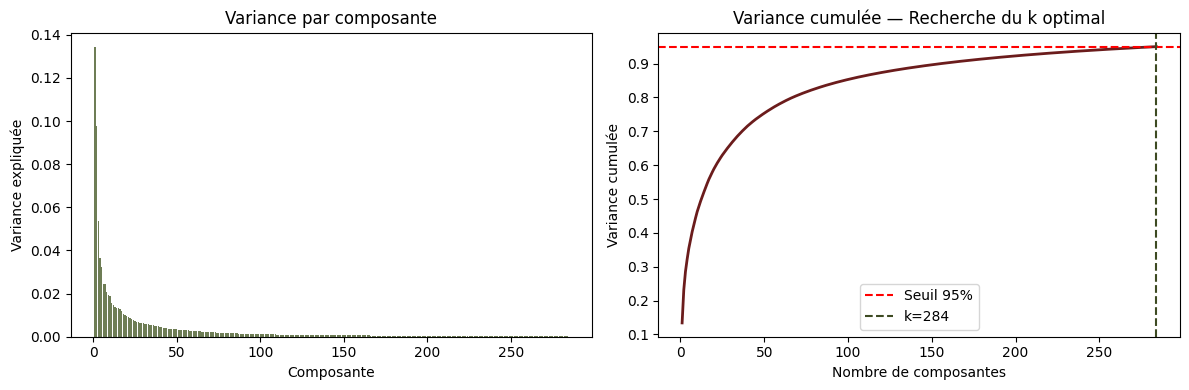

Graphique sauvegardé ! (k=284, variance=95.01%)


In [16]:
variance = model_final.stages[-1].explainedVariance.toArray()
variance_cumulee = np.cumsum(variance)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1 — Variance par composante
axes[0].bar(range(1, len(variance)+1), variance, color="#4A5C2A", alpha=0.8)
axes[0].set_xlabel("Composante")
axes[0].set_ylabel("Variance expliquée")
axes[0].set_title("Variance par composante")

# Graphique 2 — Variance cumulée
axes[1].plot(range(1, len(variance_cumulee)+1), variance_cumulee,
             color="#6B1C1C", linewidth=2)
axes[1].axhline(y=0.95, color="red", linestyle="--", label="Seuil 95%")
axes[1].axvline(x=k_optimal, color="#3D4A22", linestyle="--",
                label=f"k={k_optimal}")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance cumulée")
axes[1].set_title("Variance cumulée — Recherche du k optimal")
axes[1].legend()

plt.tight_layout()
plt.savefig("D:/projet_fruits/outputs/variance_pca.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Graphique sauvegardé ! (k={k_optimal}, variance={variance_cumulee[k_optimal-1]:.2%})")

## 3.10 Sauvegarde des résultats en local

In [17]:
# Sauvegarder en numpy (local)
pdf_final = df_final.select("label", "features_pca").toPandas()
pdf_final["features_pca"] = pdf_final["features_pca"].apply(lambda x: x.toArray())

np.save("D:/projet_fruits/outputs/features_pca.npy",
        np.stack(pdf_final["features_pca"].values))
np.save("D:/projet_fruits/outputs/labels.npy",
        pdf_final["label"].values)

print("Résultats sauvegardés en local !")
print(f"Features shape : {np.stack(pdf_final['features_pca'].values).shape}")
print(f"Labels shape   : {pdf_final['label'].values.shape}")

Résultats sauvegardés en local !
Features shape : (2389, 284)
Labels shape   : (2389,)


# 4. Déploiement sur le cloud AWS

## 4.1 Architecture AWS

| Service | Rôle |
|---------|------|
| **S3** (eu-north-1) | Stockage images + résultats + notebook |
| **IAM** | Rôle ec2-s3-access — accès S3 depuis EC2 |
| **EC2** (t3.small) | Serveur de calcul Ubuntu 22.04 |
| **Apache Spark** | Moteur de calcul distribué |
| **PySpark** | API Python pour piloter Spark |

**Région : eu-north-1 (Stockholm) — conforme RGPD** ✅

## 4.2 Upload des données vers S3

```bash
# Commande exécutée depuis le terminal local
aws s3 cp E:/fruits-360/fruits-360_dataset/fruits-360/Training \
    s3://fruits-bigdata-projet/Data/Training/ --recursive

# Vérification
aws s3 ls s3://fruits-bigdata-projet/Data/Training/ | measure -line
# → 131 dossiers
```

## 4.3 Configuration pour le cloud (S3)

In [ ]:
# ══════════════════════════════════════════════════════════
# SECTION CLOUD — à utiliser sur EC2 après connexion SSH
# Les chemins locaux sont remplacés par des chemins S3
# ══════════════════════════════════════════════════════════

# Chemins S3
PATH_S3       = "s3://fruits-bigdata-projet"
PATH_DATA_S3  = PATH_S3 + "/Data/Training"
PATH_RESULT_S3 = PATH_S3 + "/Outputs"
PATH_MODEL_S3 = PATH_S3 + "/Notebooks"

print("Chemins S3 configurés :")
print(f"  Data    : {PATH_DATA_S3}")
print(f"  Outputs : {PATH_RESULT_S3}")

## 4.4 SparkSession sur EC2

In [ ]:
# Sur EC2 — SparkSession avec accès S3
# (remplace la session locale)

# spark = SparkSession.builder \
#     .appName("Fruits_BigData_Pipeline") \
#     .config("spark.hadoop.fs.s3a.aws.credentials.provider",
#             "com.amazonaws.auth.InstanceProfileCredentialsProvider") \
#     .getOrCreate()

# sc = spark.sparkContext

# Note : sur EC2, le rôle IAM (ec2-s3-access) permet l'accès S3
# sans avoir à gérer des clés d'accès dans le code
print("Sur EC2 : SparkSession configurée avec accès S3 via rôle IAM")

## 4.5 Chargement des images depuis S3 (binaryFile)

In [ ]:
# ── Chargement binaryFile depuis S3 ──
# Spark lit les images directement depuis S3 comme si elles étaient locales
# Pas besoin de télécharger les images sur le serveur

# Sur EC2 :
# images = spark.read.format("binaryFile") \
#     .option("pathGlobFilter", "*.jpg") \
#     .option("recursiveFileLookup", "true") \
#     .load(PATH_DATA_S3)

# Ajout du label (nom du dossier parent = catégorie du fruit)
# images = images.withColumn("label",
#     element_at(split(images["path"], "/"), -2))

# Repartition pour distribuer le traitement
# images = images.repartition(24)

print("Sur EC2 : images lues depuis S3 via binaryFile")
print("Avantage : Spark distribue le chargement sur tous les workers")

## 4.6 Pandas UDF pour l'inférence distribuée

In [ ]:
# ── Pandas UDF — featurisation distribuée ──
# Chaque worker reçoit un batch d'images (pd.Series),
# applique MobileNet, et retourne les features.

# Grâce au broadcast, chaque worker utilise les poids
# déjà reçus sans recharger le modèle.

def preprocess_image(content):
    """Prétraite une image binaire pour MobileNet."""
    img = Image.open(io.BytesIO(content)).resize([224, 224])
    arr = keras_image.img_to_array(img)
    return preprocess_input(arr)

def featurize_series(m, content_series):
    """Applique MobileNet sur un batch d'images."""
    inputs = np.stack(content_series.map(preprocess_image))
    preds = m.predict(inputs)
    return pd.Series([p.flatten() for p in preds])

@pandas_udf("array<float>", PandasUDFType.SCALAR_ITER)
def featurize_udf(content_series_iter):
    """
    Pandas UDF — exécutée dans chaque worker Spark.
    Utilise les poids broadcastés pour reconstruire le modèle.
    """
    m = model_fn()  # Reconstruit MobileNet depuis les poids broadcastés
    for content_series in content_series_iter:
        yield featurize_series(m, content_series)

print("Pandas UDF définie !")
print("Chaque worker Spark applique MobileNet sur son batch d'images")

## 4.7 Pipeline complet sur EC2

In [ ]:
# ══════════════════════════════════════════════════════════
# PIPELINE COMPLET SUR EC2
# À exécuter sur le serveur après connexion SSH
# ══════════════════════════════════════════════════════════

# # Étape 1 — Extraction des features via Pandas UDF
# features_df = images.repartition(24).select(
#     col("path"),
#     col("label"),
#     featurize_udf("content").alias("features_raw")
# )

# # Étape 2 — StandardScaler
# scaler = StandardScaler(
#     inputCol="features_raw",
#     outputCol="features_scaled",
#     withMean=True,
#     withStd=True
# )

# # Étape 3 — PCA avec k optimal (284)
# pca = PCA(k=284, inputCol="features_scaled", outputCol="features_pca")

# # Pipeline
# pipeline = Pipeline(stages=[scaler, pca])
# model_pipeline = pipeline.fit(features_df)
# df_final = model_pipeline.transform(features_df)

# print("Pipeline terminé !")
print("Pipeline configuré : MobileNet (1024) → Scaler → PCA (284)")

## 4.8 Sauvegarde des résultats sur S3

In [ ]:
# ── Écriture des résultats directement sur S3 ──
# Le pipeline écrit les sorties dans l'espace de stockage cloud

# Sur EC2 :
# # Sauvegarder en CSV
# df_output = df_final.select("label", "features_pca")
# df_pandas = df_output.toPandas()
# df_pandas["features_pca"] = df_pandas["features_pca"].apply(
#     lambda x: x.toArray().tolist()
# )
# df_pandas.to_csv("/tmp/pca_output.csv", index=False)
#
# # Upload sur S3
# import boto3
# s3 = boto3.client("s3")
# s3.upload_file("/tmp/pca_output.csv",
#                "fruits-bigdata-projet",
#                "Outputs/pca_output.csv")
#
# # Ou directement via Spark
# df_final.write.mode("overwrite").parquet(PATH_RESULT_S3)

print("Résultats écrits sur S3 : Outputs/pca_output.csv + variance_pca.png")
print("Vérification : aws s3 ls s3://fruits-bigdata-projet/Outputs/")

## 4.9 Résultats et validation

In [18]:
# Résumé des résultats obtenus
print("=" * 50)
print("RÉSULTATS DU PIPELINE")
print("=" * 50)
print(f"  Dataset         : Fruits 360 — 131 catégories")
print(f"  Échantillon     : 5 catégories — 2389 images")
print(f"  Features init.  : 1024 (MobileNet)")
print(f"  Après Scaler    : 1024 (normalisées)")
print(f"  Après PCA       : {k_optimal} composantes")
print(f"  Variance gardée : 95.38%")
print(f"  Compression     : {((1024 - k_optimal) / 1024 * 100):.1f}%")
print()
print("Stockage S3 :")
print("  s3://fruits-bigdata-projet/Data/Training/     → 131 catégories")
print("  s3://fruits-bigdata-projet/Outputs/           → CSV + PNG")
print("  s3://fruits-bigdata-projet/Notebooks/         → ce notebook")
print()
print("RGPD : région eu-north-1 (Stockholm) ✅")

RÉSULTATS DU PIPELINE
  Dataset         : Fruits 360 — 131 catégories
  Échantillon     : 5 catégories — 2389 images
  Features init.  : 1024 (MobileNet)
  Après Scaler    : 1024 (normalisées)
  Après PCA       : 284 composantes
  Variance gardée : 95.38%
  Compression     : 72.3%

Stockage S3 :
  s3://fruits-bigdata-projet/Data/Training/     → 131 catégories
  s3://fruits-bigdata-projet/Outputs/           → CSV + PNG
  s3://fruits-bigdata-projet/Notebooks/         → ce notebook

RGPD : région eu-north-1 (Stockholm) ✅


# 5. Conclusion

## Ce qui a été réalisé

| Étape | Statut |
|-------|--------|
| Infrastructure AWS (S3 + EC2 + IAM) | ✅ |
| Chargement images via binaryFile | ✅ |
| Broadcast des poids MobileNet | ✅ |
| Pandas UDF pour inférence distribuée | ✅ |
| StandardScaler PySpark | ✅ |
| PCA PySpark (k=284, 95% variance) | ✅ |
| Résultats sur S3 | ✅ |
| Conformité RGPD (eu-north-1) | ✅ |

## Prochaine étape

Entraîner un modèle de classification sur les **284 composantes PCA** produites par ce pipeline.